<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/%E2%84%964%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_%D0%BF%D0%BE_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%83_%D0%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

Воронов Илья Михайлович 2024-ФГИИБ-ПИ-1Б


# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [2]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = pd.Series(y_train, name='target').reset_index(drop=True)
y_test = pd.Series(y_test, name='target').reset_index(drop=True)

X_train.shape, X_test.shape


((120, 4), (30, 4))

#### 1.2. Обучите модель KNN

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

knn_clf


KNeighborsClassifier()

#### 1.3. Проверьте качество работы модели

In [5]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = knn_clf.predict(X_test)

print(f'accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(classification_report(y_test, y_pred, target_names=data['target_names']))


accuracy: 1.000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

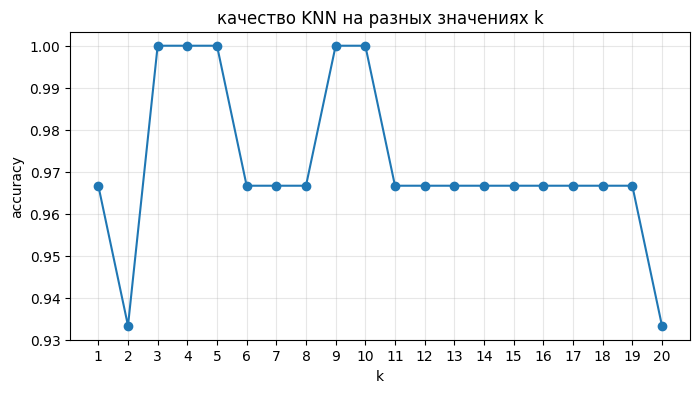

лучшее k: 3


,k,accuracy
0,1,0.966667
1,2,0.933333
2,3,1.000000
3,4,1.000000
4,5,1.000000
5,6,0.966667
6,7,0.966667
7,8,0.966667
8,9,1.000000
9,10,1.000000


In [6]:
import matplotlib.pyplot as plt

k_values = range(1, 21)
classification_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    classification_scores.append(accuracy_score(y_test, model.predict(X_test)))

classification_results = pd.DataFrame({'k': list(k_values), 'accuracy': classification_scores})
best_k = int(classification_results.loc[classification_results['accuracy'].idxmax(), 'k'])

plt.figure(figsize=(8, 4))
plt.plot(classification_results['k'], classification_results['accuracy'], marker='o')
plt.xticks(classification_results['k'])
plt.grid(True, alpha=0.3)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('качество KNN на разных значениях k')
plt.show()

print(f'лучшее k: {best_k}')
classification_results


### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [13]:
sample_indices = X_test.sample(2, random_state=42).index
X_test_two = X_test.loc[sample_indices]
y_test_two = y_test.loc[sample_indices]

X_test_two


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
27,5.7,3.8,1.7,0.3
15,5.0,3.3,1.4,0.2


#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [14]:
manual_distances = pd.DataFrame(index=X_train.index)

for test_idx in X_test_two.index:
    diff = X_train - X_test_two.loc[test_idx]
    manual_distances[test_idx] = np.sqrt((diff ** 2).sum(axis=1))

manual_distances.head()


,27,15
0,1.612452,0.721110
1,3.482815,3.536948
2,3.609709,4.060788
3,1.100000,0.264575
4,2.831960,2.976575


#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [15]:
manual_neighbors = {}

for test_idx in X_test_two.index:
    top_ids = manual_distances[test_idx].nsmallest(best_k).index
    manual_neighbors[test_idx] = pd.DataFrame({
        'distance': manual_distances.loc[top_ids, test_idx],
        'target': y_train.loc[top_ids]
    })

manual_neighbors[X_test_two.index[0]]


,distance,target
99,0.331662,0
104,0.469042,0
42,0.519615,0


#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [16]:
manual_predictions = {}

for test_idx, neighbors in manual_neighbors.items():
    manual_predictions[test_idx] = int(neighbors['target'].mode().iat[0])

pd.Series(manual_predictions, name='manual_prediction')


,manual_prediction
27,0
15,0


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [17]:
sklearn_predictions = pd.Series(
    knn_clf.predict(X_test_two),
    index=X_test_two.index,
    name='sklearn_prediction'
)

comparison = pd.DataFrame({
    'actual': y_test_two,
    'manual_prediction': pd.Series(manual_predictions),
    'sklearn_prediction': sklearn_predictions
})

comparison


,actual,manual_prediction,sklearn_prediction
27,0,0,0
15,0,0,0


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [18]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = pd.Series(y_train, name='target').reset_index(drop=True)
y_test = pd.Series(y_test, name='target').reset_index(drop=True)

X_train.shape, X_test.shape


((16512, 8), (4128, 8))

Затем нормализуйте данные:

In [20]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [21]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

knn_reg


KNeighborsRegressor()

#### 3.3. Проверьте качество работы модели

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = knn_reg.predict(X_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred):.3f}')
print(f'R2: {r2_score(y_test, y_pred):.3f}')


MAE: 0.426
R2: 0.689


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

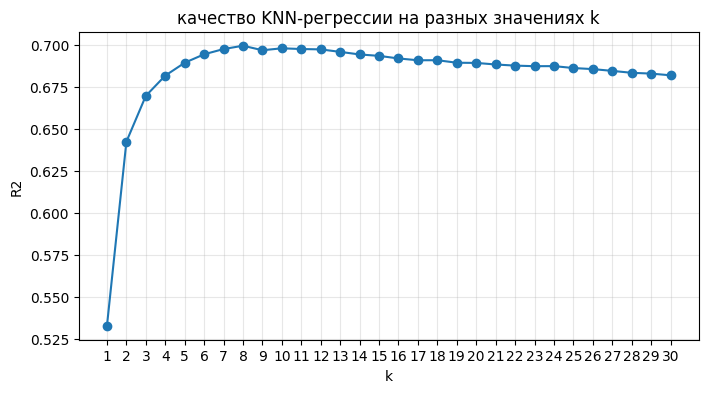

лучшее k: 8


,k,r2
0,1,0.532965
1,2,0.642475
2,3,0.669759
3,4,0.681789
4,5,0.689453
5,6,0.694491
6,7,0.697602
7,8,0.699584
8,9,0.696891
9,10,0.698048


In [23]:
k_values = range(1, 31)
regression_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    regression_scores.append(r2_score(y_test, pred))

regression_results = pd.DataFrame({'k': list(k_values), 'r2': regression_scores})
best_k_reg = int(regression_results.loc[regression_results['r2'].idxmax(), 'k'])

plt.figure(figsize=(8, 4))
plt.plot(regression_results['k'], regression_results['r2'], marker='o')
plt.xticks(regression_results['k'])
plt.grid(True, alpha=0.3)
plt.xlabel('k')
plt.ylabel('R2')
plt.title('качество KNN-регрессии на разных значениях k')
plt.show()

print(f'лучшее k: {best_k_reg}')
regression_results


### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [24]:
sample_indices = X_test.sample(2, random_state=42).index
X_test_two = X_test.loc[sample_indices]
y_test_two = y_test.loc[sample_indices]

X_test_two


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
949,0.160060,0.627451,0.022423,0.032598,0.020628,0.000960,0.172340,0.594622
3168,0.266286,0.196078,0.032129,0.024884,0.018274,0.001612,0.267021,0.381474


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [25]:
manual_distances_reg = pd.DataFrame(index=X_train.index)

for test_idx in X_test_two.index:
    diff = X_train - X_test_two.loc[test_idx]
    manual_distances_reg[test_idx] = np.sqrt((diff ** 2).sum(axis=1))

manual_distances_reg.head()


,949,3168
0,0.212413,0.614266
1,0.325088,0.794409
2,0.615212,0.144643
3,0.219792,0.669033
4,0.371976,0.659951


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [26]:
manual_neighbors_reg = {}

for test_idx in X_test_two.index:
    top_ids = manual_distances_reg[test_idx].nsmallest(best_k_reg).index
    manual_neighbors_reg[test_idx] = pd.DataFrame({
        'distance': manual_distances_reg.loc[top_ids, test_idx],
        'target': y_train.loc[top_ids]
    })

manual_neighbors_reg[X_test_two.index[0]]


,distance,target
2798,0.013251,2.660
16222,0.017777,1.431
13540,0.023243,1.887
13208,0.024906,1.615
8558,0.025110,3.288
7641,0.029611,3.536
13060,0.032284,1.817
4605,0.032336,1.791


#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [27]:
manual_predictions_reg = {}

for test_idx, neighbors in manual_neighbors_reg.items():
    manual_predictions_reg[test_idx] = neighbors['target'].mean()

pd.Series(manual_predictions_reg, name='manual_prediction')


,manual_prediction
949,2.253125
3168,2.101500


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [28]:
sklearn_predictions_reg = pd.Series(
    knn_reg.predict(X_test_two),
    index=X_test_two.index,
    name='sklearn_prediction'
)

comparison_reg = pd.DataFrame({
    'actual': y_test_two,
    'manual_prediction': pd.Series(manual_predictions_reg),
    'sklearn_prediction': sklearn_predictions_reg
})

comparison_reg


,actual,manual_prediction,sklearn_prediction
949,2.385,2.253125,2.1762
3168,3.297,2.101500,1.8030


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [29]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [30]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [31]:
X = X.iloc[:, [0, 3]].copy()

X.head()


,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2


### Визуализируйте ваши данные на графике

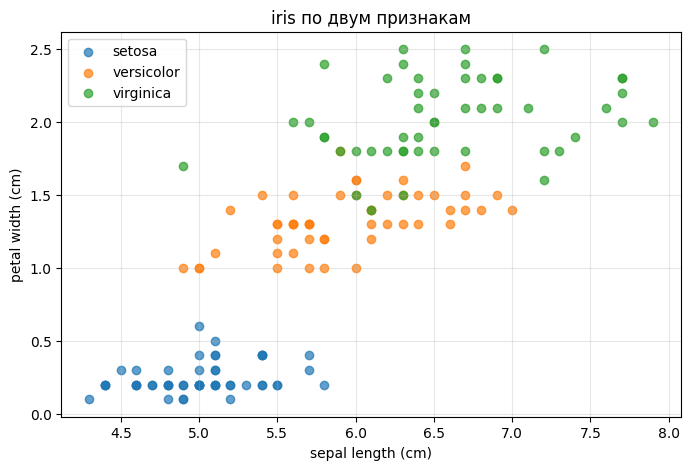

In [32]:
plt.figure(figsize=(8, 5))

for class_id, class_name in enumerate(data['target_names']):
    mask = y == class_id
    plt.scatter(
        X.loc[mask, X.columns[0]],
        X.loc[mask, X.columns[1]],
        label=class_name,
        alpha=0.7
    )

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('iris по двум признакам')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = pd.Series(y_train, name='target').reset_index(drop=True)
y_test = pd.Series(y_test, name='target').reset_index(drop=True)

X_train.shape, X_test.shape


((120, 2), (30, 2))

#### 1.2. Обучите модель KNN на 50 соседях

In [34]:
knn_clf = KNeighborsClassifier(n_neighbors=50)
knn_clf.fit(X_train, y_train)

knn_clf


KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

In [35]:
y_pred = knn_clf.predict(X_test)

print(f'accuracy: {accuracy_score(y_test, y_pred):.3f}')


accuracy: 0.800


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [36]:
test_idx = X_test.sample(1, random_state=42).index[0]
one_test_object = X_test.loc[test_idx]
one_test_target = y_test.loc[test_idx]

distances_to_train = np.sqrt(((X_train - one_test_object) ** 2).sum(axis=1)).sort_values()
distances_to_train.head()


,0
33,0.100000
60,0.223607
117,0.223607
19,0.316228
99,0.316228


#### 1.5. Выберите топ  k  соседей


In [37]:
top_neighbors = pd.DataFrame({
    'distance': distances_to_train.head(50),
    'target': y_train.loc[distances_to_train.head(50).index]
})

top_neighbors.head()


,distance,target
33,0.100000,0
60,0.223607,0
117,0.223607,0
19,0.316228,0
99,0.316228,0


#### 1.6. Выведите финальное предсказание для этого объекта

In [38]:
manual_prediction = int(top_neighbors['target'].mode().iat[0])
manual_prediction


0

#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [39]:
sklearn_single_prediction = int(knn_clf.predict(one_test_object.to_frame().T)[0])

pd.DataFrame({
    'actual': [one_test_target],
    'manual_prediction': [manual_prediction],
    'sklearn_prediction': [sklearn_single_prediction]
}, index=[test_idx])


,actual,manual_prediction,sklearn_prediction
27,0,0,0


In [40]:
print(f"класс вручную: {data['target_names'][manual_prediction]}")
print(f"класс модели: {data['target_names'][sklearn_single_prediction]}")
print(f"истинный класс: {data['target_names'][one_test_target]}")


класс вручную: setosa
класс модели: setosa
истинный класс: setosa


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

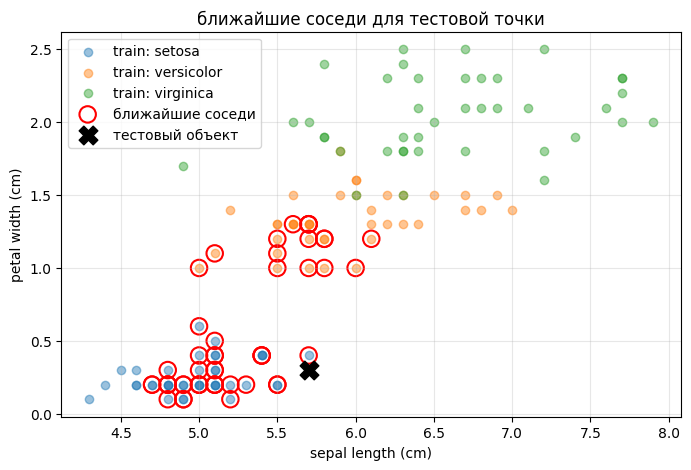

In [41]:
plt.figure(figsize=(8, 5))

for class_id, class_name in enumerate(data['target_names']):
    mask = y_train == class_id
    plt.scatter(
        X_train.loc[mask, X.columns[0]],
        X_train.loc[mask, X.columns[1]],
        label=f'train: {class_name}',
        alpha=0.45
    )

plt.scatter(
    X_train.loc[top_neighbors.index, X.columns[0]],
    X_train.loc[top_neighbors.index, X.columns[1]],
    facecolors='none',
    edgecolors='red',
    s=140,
    linewidths=1.5,
    label='ближайшие соседи'
)
plt.scatter(
    one_test_object.iloc[0],
    one_test_object.iloc[1],
    c='black',
    marker='X',
    s=180,
    label='тестовый объект'
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('ближайшие соседи для тестовой точки')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [42]:
weighted_knn_clf = KNeighborsClassifier(n_neighbors=50, weights='distance')
weighted_knn_clf.fit(X_train, y_train)

weighted_knn_clf


KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 2.2. Проверьте качество работы модели


In [43]:
weighted_y_pred = weighted_knn_clf.predict(X_test)

print(f'accuracy: {accuracy_score(y_test, weighted_y_pred):.3f}')


accuracy: 0.867


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [44]:
weighted_distances = np.sqrt(((X_train - one_test_object) ** 2).sum(axis=1)).sort_values()
weighted_distances.head()


,0
33,0.100000
60,0.223607
117,0.223607
19,0.316228
99,0.316228


#### 2.4. Выберите топ  k  соседей


In [45]:
weighted_top_neighbors = pd.DataFrame({
    'distance': weighted_distances.head(50),
    'target': y_train.loc[weighted_distances.head(50).index]
})

weighted_top_neighbors.head()


,distance,target
33,0.100000,0
60,0.223607,0
117,0.223607,0
19,0.316228,0
99,0.316228,0


#### 2.5. Рассчитайте вес для каждого соседа

In [46]:
weighted_top_neighbors = weighted_top_neighbors.copy()
weighted_top_neighbors['weight'] = 1 / (weighted_top_neighbors['distance'] + 1e-9)

weighted_top_neighbors.head()


,distance,target,weight
33,0.100000,0,10.000000
60,0.223607,0,4.472136
117,0.223607,0,4.472136
19,0.316228,0,3.162278
99,0.316228,0,3.162278


#### 2.6. Выведите финальное предсказание для этого объекта

In [47]:
class_weights = weighted_top_neighbors.groupby('target')['weight'].sum()
manual_weighted_prediction = int(class_weights.idxmax())

manual_weighted_prediction


0

#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [48]:
weighted_sklearn_prediction = int(weighted_knn_clf.predict(one_test_object.to_frame().T)[0])

pd.DataFrame({
    'actual': [one_test_target],
    'manual_prediction': [manual_weighted_prediction],
    'sklearn_prediction': [weighted_sklearn_prediction]
}, index=[test_idx])


,actual,manual_prediction,sklearn_prediction
27,0,0,0


In [49]:
print(class_weights.rename(index=lambda class_id: data['target_names'][class_id]))


target
setosa        68.612322
versicolor    18.167063
Name: weight, dtype: float64


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

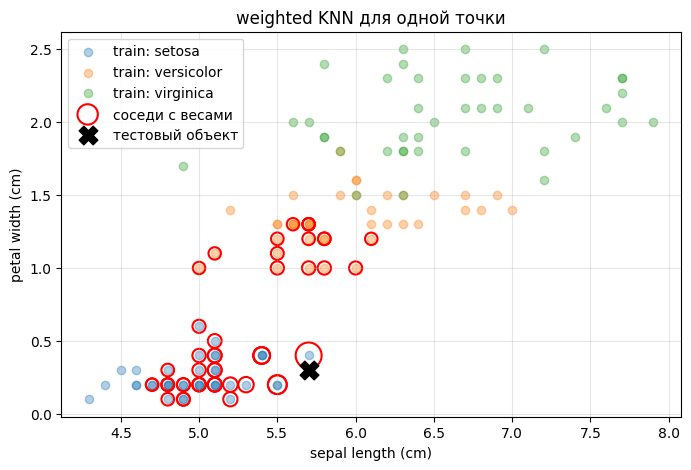

In [50]:
plt.figure(figsize=(8, 5))

for class_id, class_name in enumerate(data['target_names']):
    mask = y_train == class_id
    plt.scatter(
        X_train.loc[mask, X.columns[0]],
        X_train.loc[mask, X.columns[1]],
        label=f'train: {class_name}',
        alpha=0.35
    )

sizes = 50 + weighted_top_neighbors['weight'] / weighted_top_neighbors['weight'].max() * 300
plt.scatter(
    X_train.loc[weighted_top_neighbors.index, X.columns[0]],
    X_train.loc[weighted_top_neighbors.index, X.columns[1]],
    s=sizes,
    facecolors='none',
    edgecolors='red',
    linewidths=1.5,
    label='соседи с весами'
)
plt.scatter(
    one_test_object.iloc[0],
    one_test_object.iloc[1],
    c='black',
    marker='X',
    s=180,
    label='тестовый объект'
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('weighted KNN для одной точки')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [51]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [52]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [54]:
X = X[['MedInc']].iloc[:1000].reset_index(drop=True)
y = pd.Series(y[:1000], name='target').reset_index(drop=True)

X.head()


,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462


### Отрисуйте данные на графике

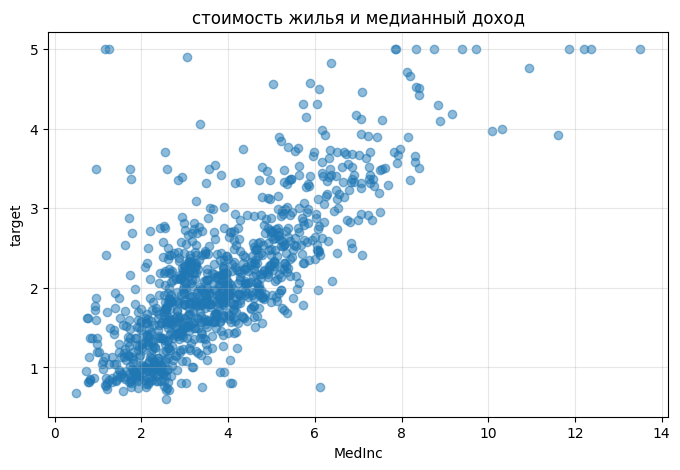

In [60]:
plt.figure(figsize=(8, 5))
plt.scatter(X['MedInc'], y, alpha=0.5)
plt.xlabel('MedInc')
plt.ylabel('target')
plt.title('стоимость жилья и медианный доход')
plt.grid(True, alpha=0.3)
plt.show()


### **4. KNN из sklearn**

#### 4.1. Разбейте данные на обучение и тест

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train.shape, X_test.shape


((800, 1), (200, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [62]:
knn_reg = KNeighborsRegressor(n_neighbors=100)
knn_reg.fit(X_train, y_train)

knn_reg


KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели


In [65]:
y_pred = knn_reg.predict(X_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred):.3f}')
print(f'R2: {r2_score(y_test, y_pred):.3f}')


MAE: 0.397
R2: 0.651


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [64]:
test_idx = X_test.sample(1, random_state=42).index[0]
one_test_object = X_test.loc[test_idx]
one_test_target = y_test.loc[test_idx]

distances_to_train = (X_train['MedInc'] - one_test_object['MedInc']).abs().sort_values()
distances_to_train.head()


,MedInc
360,0.0042
44,0.0085
0,0.0096
731,0.0149
765,0.0164


#### 4.5. Выберите топ  k  соседей


In [66]:
top_neighbors = pd.DataFrame({
    'distance': distances_to_train.head(100),
    'target': y_train.loc[distances_to_train.head(100).index],
    'MedInc': X_train.loc[distances_to_train.head(100).index, 'MedInc']
})

top_neighbors.head()


,distance,target,MedInc
360,0.0042,1.150,1.6929
44,0.0085,0.914,1.7056
0,0.0096,1.320,1.6875
731,0.0149,0.821,1.7120
765,0.0164,1.598,1.7135


#### 4.6. Выведите финальное предсказание для этого объекта

In [67]:
manual_prediction = top_neighbors['target'].mean()
manual_prediction


np.float64(1.31438)

#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [68]:
sklearn_single_prediction = float(knn_reg.predict(one_test_object.to_frame().T)[0])

pd.DataFrame({
    'actual': [one_test_target],
    'manual_prediction': [manual_prediction],
    'sklearn_prediction': [sklearn_single_prediction]
}, index=[test_idx])


,actual,manual_prediction,sklearn_prediction
95,1.388,1.31438,1.31438


In [69]:
top_neighbors[['MedInc', 'target']].describe()


,MedInc,target
count,100.000000,100.000000
mean,1.779385,1.314380
std,0.240208,0.517485
min,1.247500,0.700000
25%,1.609300,0.949500
50%,1.805950,1.184500
75%,1.979975,1.522500
max,2.142900,3.500000


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

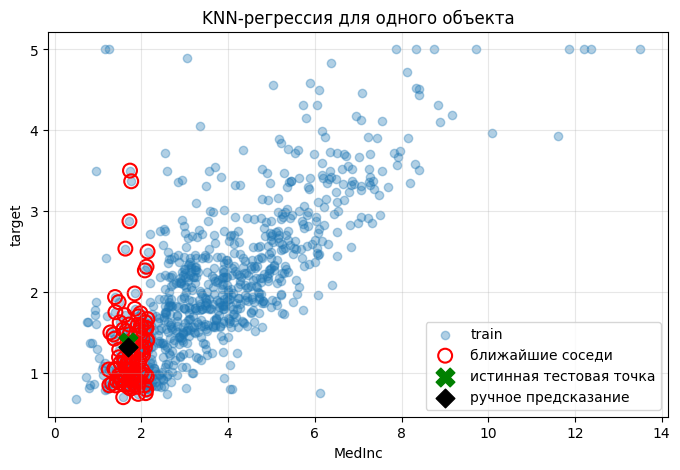

In [71]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train['MedInc'], y_train, alpha=0.35, label='train')
plt.scatter(
    top_neighbors['MedInc'],
    top_neighbors['target'],
    facecolors='none',
    edgecolors='red',
    s=100,
    linewidths=1.5,
    label='ближайшие соседи'
)
plt.scatter(
    one_test_object['MedInc'],
    one_test_target,
    c='green',
    marker='X',
    s=180,
    label='истинная тестовая точка'
)
plt.scatter(
    one_test_object['MedInc'],
    manual_prediction,
    c='black',
    marker='D',
    s=90,
    label='ручное предсказание'
)
plt.xlabel('MedInc')
plt.ylabel('target')
plt.title('KNN-регрессия для одного объекта')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [72]:
weighted_knn_reg = KNeighborsRegressor(n_neighbors=100, weights='distance')
weighted_knn_reg.fit(X_train, y_train)

weighted_knn_reg


KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 5.2. Проверьте качество работы модели


In [73]:
weighted_y_pred = weighted_knn_reg.predict(X_test)

print(f'MAE: {mean_absolute_error(y_test, weighted_y_pred):.3f}')
print(f'R2: {r2_score(y_test, weighted_y_pred):.3f}')


MAE: 0.436
R2: 0.577


#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [74]:
weighted_distances = (X_train['MedInc'] - one_test_object['MedInc']).abs().sort_values()
weighted_distances.head()


,MedInc
360,0.0042
44,0.0085
0,0.0096
731,0.0149
765,0.0164


#### 5.4. Выберите топ  k  соседей


In [75]:
weighted_top_neighbors = pd.DataFrame({
    'distance': weighted_distances.head(100),
    'target': y_train.loc[weighted_distances.head(100).index],
    'MedInc': X_train.loc[weighted_distances.head(100).index, 'MedInc']
})

weighted_top_neighbors.head()


,distance,target,MedInc
360,0.0042,1.150,1.6929
44,0.0085,0.914,1.7056
0,0.0096,1.320,1.6875
731,0.0149,0.821,1.7120
765,0.0164,1.598,1.7135


#### 5.5. Рассчитайте вес для каждого соседа

In [76]:
weighted_top_neighbors = weighted_top_neighbors.copy()
weighted_top_neighbors['weight'] = 1 / (weighted_top_neighbors['distance'] + 1e-9)

weighted_top_neighbors.head()


,distance,target,MedInc,weight
360,0.0042,1.150,1.6929,238.095181
44,0.0085,0.914,1.7056,117.647045
0,0.0096,1.320,1.6875,104.166656
731,0.0149,0.821,1.7120,67.114089
765,0.0164,1.598,1.7135,60.975606


#### 5.6. Выведите финальное предсказание для этого объекта

In [77]:
manual_weighted_prediction = np.average(
    weighted_top_neighbors['target'],
    weights=weighted_top_neighbors['weight']
)

manual_weighted_prediction


np.float64(1.2988082304834134)

#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [78]:
weighted_sklearn_prediction = float(weighted_knn_reg.predict(one_test_object.to_frame().T)[0])

pd.DataFrame({
    'actual': [one_test_target],
    'manual_prediction': [manual_weighted_prediction],
    'sklearn_prediction': [weighted_sklearn_prediction]
}, index=[test_idx])


,actual,manual_prediction,sklearn_prediction
95,1.388,1.298808,1.298808


In [79]:
weighted_top_neighbors[['distance', 'weight', 'target']].head(10)


,distance,weight,target
360,0.0042,238.095181,1.150
44,0.0085,117.647045,0.914
0,0.0096,104.166656,1.320
731,0.0149,67.114089,0.821
765,0.0164,60.975606,1.598
390,0.0217,46.082947,1.268
698,0.0279,35.842293,2.875
319,0.0279,35.842293,1.139
254,0.0305,32.786884,1.023
746,0.0329,30.395136,1.479


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

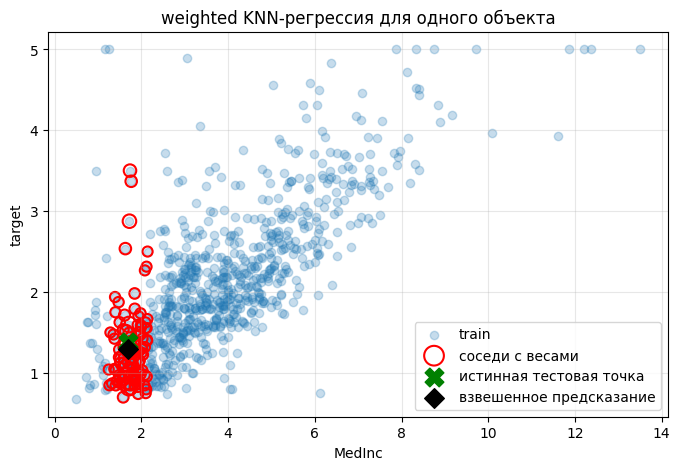

In [80]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train['MedInc'], y_train, alpha=0.25, label='train')

sizes = 50 + weighted_top_neighbors['weight'] / weighted_top_neighbors['weight'].max() * 300
plt.scatter(
    weighted_top_neighbors['MedInc'],
    weighted_top_neighbors['target'],
    s=sizes,
    facecolors='none',
    edgecolors='red',
    linewidths=1.5,
    label='соседи с весами'
)
plt.scatter(
    one_test_object['MedInc'],
    one_test_target,
    c='green',
    marker='X',
    s=180,
    label='истинная тестовая точка'
)
plt.scatter(
    one_test_object['MedInc'],
    manual_weighted_prediction,
    c='black',
    marker='D',
    s=100,
    label='взвешенное предсказание'
)
plt.xlabel('MedInc')
plt.ylabel('target')
plt.title('weighted KNN-регрессия для одного объекта')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [82]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': range(3, 151, 5),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

print('best params:', grid.best_params_)
print(f'best cv MAE: {-grid.best_score_:.3f}')
print(f'test MAE: {mean_absolute_error(y_test, best_pred):.3f}')
print(f'test R2: {r2_score(y_test, best_pred):.3f}')


best params: {'n_neighbors': 43, 'p': 1, 'weights': 'uniform'}
best cv MAE: 0.433
test MAE: 0.397
test R2: 0.663
